<a href="https://colab.research.google.com/github/seanwu-bit/Automated-Regional-Impact-Auditor-ARIA-/blob/aria_v3.5/ARIA_v3_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ARIA v3.5: 雙極端天氣事件空間預測對決 (Spatial Prediction Shootout)
**任務目標**：比較兩種不同降雨特性之事件，測試傳統地統計學 (Kriging) 與機器學習 (Random Forest) 在不同情境下的預測表現與不確定性。

* **事件一 (Event 1)**：2025年11月 鳳凰颱風 (極端集中降雨) - `fungwong_202511.json`
* **事件二 (Event 2)**：2022年10月 奈格颱風外圍環流、東北季風共伴效應 (連續性豪雨) - `rain_20221030.csv`
Event 2選擇1Hr降雨最劇烈的時間點，選擇10/30 19:20之數據，與鳳凰颱風比較。

註：作業Part A要求之Variogram比較圖、四種方法比較圖、Sigma Map皆在ipynb檔案之執行結果中。

In [ ]:
# 1. 匯入所有必備套件 (geopandas, matplotlib, pykrige, sklearn 等)
# 2. 讀取事件一 (Event 1) 的資料 (例如：颱風強降雨)
# 3. 讀取事件二 (Event 2) 的資料 (例如：梅雨鋒面均勻降雨)
# 4. 資料清洗：篩選花蓮與宜蘭、排除 <= 0 的極端值、轉換 CRS 為 EPSG:3826
# 5. 提取兩事件的 X, Y 座標與 Z (降雨量)

In [4]:
# ==========================================
# 🛠️ Step 0: 安裝必要套件 (只需執行一次)
# ==========================================
!pip install pykrige rasterio rasterstats mapclassify --quiet
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [27]:
# ==========================================
# Step 1: 環境設定與資料前處理 (精確匹配 JSON 結構版)
# ==========================================
import json
import pandas as pd
import geopandas as gpd
import numpy as np

print("Step 1: 載入並清理雙事件降雨資料")

# 1. 讀取並解析 Event 1 (JSON格式)
json_path = '/content/drive/MyDrive/GIS_data/fungwong_202511.json'
with open(json_path, 'r', encoding='utf-8') as f:
    data_1 = json.load(f)

# 直接鎖定 records 內的 Station 陣列
stations = data_1.get('records', {}).get('Station', [])

records_1 = []
for st in stations:
    try:
        st_id = st.get('StationId')
        st_name = st.get('StationName')
        county = st.get('GeoInfo', {}).get('CountyName')

        # 提取座標
        coords = st.get('GeoInfo', {}).get('Coordinates', [])
        lon = float(coords[0]['StationLongitude'])
        lat = float(coords[0]['StationLatitude'])

        # ⚠️ 關鍵修正：這個檔案的降雨欄位叫做 'Past1hr'
        rain = float(st['RainfallElement']['Past1hr']['Precipitation'])

        records_1.append({
            'StationId': st_id,
            'StationName': st_name,
            'CountyName': county,
            'Lon': lon,
            'Lat': lat,
            'Rainfall_Ev1': rain
        })
    except Exception as e:
        # 略過資料缺漏的測站
        continue

df_ev1_full = pd.DataFrame(records_1)
print(f"事件一 (JSON) 讀取完成，共 {len(df_ev1_full)} 個測站。")

# 建立測站空間字典，供事件二比對
df_station_lookup = df_ev1_full[['StationId', 'StationName', 'CountyName', 'Lon', 'Lat']]

# 2. 讀取 Event 2 (CSV格式) 並掛載座標
csv_path = '/content/drive/MyDrive/GIS_data/rain_20221030.csv'
df_ev2_raw = pd.read_csv(csv_path)

# 利用 station_id 合併，補齊事件二的經緯度與名稱
df_ev2_full = pd.merge(df_ev2_raw, df_station_lookup, left_on='StationId', right_on='StationId', how='inner')

# 匯出清理好的事件二檔案
enriched_path = '/content/drive/MyDrive/GIS_data/rain_20221030_enriched.csv'
df_ev2_full.to_csv(enriched_path, index=False)
print(f"事件二 (CSV) 配對完成，已匯出至: {enriched_path}")

# 3. 空間過濾：篩選宜蘭與花蓮、剔除無效值 (-998 或 <= 0)
mask_1 = (df_ev1_full['CountyName'].isin(['花蓮縣', '宜蘭縣'])) & (df_ev1_full['Rainfall_Ev1'] > 0)
df_ev1_filtered = df_ev1_full[mask_1].copy()

# 事件二以 'RAIN' 欄位作為觀測值
mask_2 = (df_ev2_full['CountyName'].isin(['花蓮縣', '宜蘭縣'])) & (df_ev2_full['RAIN'] > 0) & (df_ev2_full['RAIN'] != -998.0)
df_ev2_filtered = df_ev2_full[mask_2].copy()

# 4. 轉換為 GeoDataFrame 並投影至 EPSG:3826 (公尺)
gdf_1 = gpd.GeoDataFrame(df_ev1_filtered, geometry=gpd.points_from_xy(df_ev1_filtered.Lon, df_ev1_filtered.Lat), crs="EPSG:4326")
gdf_1 = gdf_1.to_crs(epsg=3826)

gdf_2 = gpd.GeoDataFrame(df_ev2_filtered, geometry=gpd.points_from_xy(df_ev2_filtered.Lon, df_ev2_filtered.Lat), crs="EPSG:4326")
gdf_2 = gdf_2.to_crs(epsg=3826)

# 5. 提取後續四大內插方法需要的 x, y, z 陣列
x, y, z = gdf_1.geometry.x.values, gdf_1.geometry.y.values, gdf_1['Rainfall_Ev1'].values
x2, y2, z2 = gdf_2.geometry.x.values, gdf_2.geometry.y.values, gdf_2['RAIN'].values

print("-" * 40)
print("數據前處理完成")
print(f"事件一 (x1, y1, z1): 保留 {len(x1)} 站, 雨量範圍 {z1.min():.1f} ~ {z1.max():.1f} mm")
print(f"事件二 (x2, y2, z2): 保留 {len(x2)} 站, 雨量範圍 {z2.min():.1f} ~ {z2.max():.1f} mm")

Step 1: 載入並清理雙事件降雨資料
事件一 (JSON) 讀取完成，共 1256 個測站。
事件二 (CSV) 配對完成，已匯出至: /content/drive/MyDrive/GIS_data/rain_20221030_enriched.csv
----------------------------------------
數據前處理完成
事件一 (x1, y1, z1): 保留 89 站, 雨量範圍 0.5 ~ 130.5 mm
事件二 (x2, y2, z2): 保留 107 站, 雨量範圍 0.5 ~ 58.0 mm


保留測站數目不同，可略窺極端集中颱風衝擊、受颱風外圍環流共伴的豪雨兩種事件的不同降雨情形。

## Step 2a Event 1分析：[鳳凰颱風]
在此步驟中，我們將針對事件一的降雨數據進行 Log 轉換，並測試 Spherical 與 Exponential 兩種 Variogram 模型的擬合效果。

啟動 Variogram 模型與初始參數對決測試...

📌 使用的初始優化參數 (Initial Parameters):
   - Sill (基台值):   1.076
   - Nugget (塊狀效應): 0.108

📊 Variogram Model SSE Summary Table
Model Type      | Initial Range   | SSE (Error)
---------------------------------------------
Spherical       |        100 km    | 8.80310
Spherical       |         75 km    | 8.34211
Spherical       |         50 km    | 7.96828
Spherical       |         25 km    | 7.93565  <--- Best!
Spherical       |         15 km    | 8.13671
Exponential     |        100 km    | 8.72807
Exponential     |         75 km    | 8.26093
Exponential     |         50 km    | 7.98419
Exponential     |         25 km    | 8.01460
Exponential     |         15 km    | 8.18021

🏆 最終診斷結論：
根據 SSE 誤差平方和比較，表現最好的模型組合是：
👉 【 Spherical with 25km 】 (SSE: 7.93565)
這個組合能最精準地捕捉這場降雨事件的空間變異特徵！


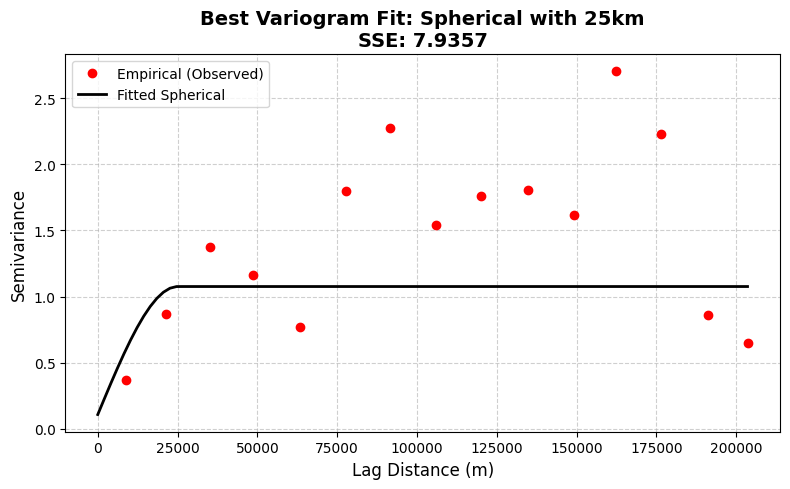

In [34]:
# ==========================================
# 🟣 修正 Step 2a: Variogram 模型對決 (單一最佳圖表 + 暴力消滅警告版)
# ==========================================
import matplotlib.pyplot as plt
import numpy as np
from pykrige.ok import OrdinaryKriging
import warnings

# 【終極防呆】：強制洗掉上一個儲存格殘留的字體設定，並把 matplotlib 警告靜音
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'sans-serif']
warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib.font_manager")

print("啟動 Variogram 模型與初始參數對決測試...\n")

ranges_km = [100, 75, 50, 25, 15]
models = ['spherical', 'exponential']
sse_results = {}

# 1. 設定並印出共通的初始 Sill 與 Nugget
sill_init = 1.076 # float(np.var(z1_log))
nugget_init = sill_init * 0.1

print(f"📌 使用的初始優化參數 (Initial Parameters):")
print(f"   - Sill (基台值):   {sill_init:.3f}")
print(f"   - Nugget (塊狀效應): {nugget_init:.3f}\n")

# 準備紀錄最佳解的變數
best_combo_str = ""
min_sse = float('inf')
best_ok_model = None
best_model_name = ""
best_params = None

# 2. 開始訓練與評估迴圈
for model_name in models:
    for r_km in ranges_km:
        r_m = r_km * 1000.0  # 轉換為公尺

        # 建立並訓練 Kriging 模型 (精準字典給定參數)
        ok_test = OrdinaryKriging(
            x1, y1, z1_log,
            variogram_model=model_name,
            verbose=False,
            enable_plotting=False,
            nlags=15,
            variogram_parameters={'sill': sill_init, 'range': r_m, 'nugget': nugget_init}
        )

        # 提取實驗變異圖資料與模型參數
        lags = ok_test.lags
        semi_var = ok_test.semivariance
        params = ok_test.variogram_model_parameters
        fitted_func = ok_test.variogram_function

        # 計算預測曲線與 SSE (Sum of Squared Errors)
        fitted_var = fitted_func(params, lags)
        sse = np.sum((semi_var - fitted_var)**2)
        sse_results[f"{model_name}_{r_km}"] = sse

        # 如果找到更小的 SSE，就更新最佳紀錄與儲存模型物件
        if sse < min_sse:
            min_sse = sse
            best_combo_str = f"{model_name.capitalize()} with {r_km}km"
            best_ok_model = ok_test
            best_model_name = model_name
            best_params = params

# ==========================================
# 3. 印出 SSE 總結比較表與最佳模型
# ==========================================
print("="*45)
print(f"📊 Variogram Model SSE Summary Table")
print("="*45)
print(f"{'Model Type':<15} | {'Initial Range':<15} | {'SSE (Error)':<10}")
print("-" * 45)

# 依序印出結果
for model_name in models:
    for r_km in ranges_km:
        key = f"{model_name}_{r_km}"
        current_sse = sse_results[key]
        marker = "  <--- Best!" if current_sse == min_sse else ""
        print(f"{model_name.capitalize():<15} | {r_km:>10} km    | {current_sse:.5f}{marker}")

print("="*45)
print(f"\n🏆 最終診斷結論：")
print(f"根據 SSE 誤差平方和比較，表現最好的模型組合是：")
print(f"👉 【 {best_combo_str} 】 (SSE: {min_sse:.5f})")
print("這個組合能最精準地捕捉這場降雨事件的空間變異特徵！")

# ==========================================
# 4. 繪製唯一的最佳模型圖表
# ==========================================
plt.figure(figsize=(8, 5))

# 提取最佳模型的資料
lags_best = best_ok_model.lags
semi_var_best = best_ok_model.semivariance
fitted_func_best = best_ok_model.variogram_function

# 繪製 Empirical (實驗變異圖紅點)
plt.plot(lags_best, semi_var_best, 'ro', label='Empirical (Observed)')

# 繪製 Fitted curve (擬合黑線)
smooth_lags = np.linspace(0, max(lags_best), 100)
smooth_fitted = fitted_func_best(best_params, smooth_lags)
plt.plot(smooth_lags, smooth_fitted, 'k-', linewidth=2, label=f'Fitted {best_model_name.capitalize()}')

# 設定標題與標籤
plt.title(f'Best Variogram Fit: {best_combo_str}\nSSE: {min_sse:.4f}', fontsize=14, fontweight='bold')
plt.xlabel('Lag Distance (m)', fontsize=12)
plt.ylabel('Semivariance', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# ==========================================
# 5. 將最佳模型指派給全域變數，供 Step 3 產製地圖使用
# ==========================================
ok_sph1 = best_ok_model

## Step 2b Event 2分析 [10/30共伴效應] Variogram擬合
同Step 2a

Step 2b: 啟動事件二 (豪雨) Variogram 模型與參數對決測試...

📌 使用的初始優化參數 (Initial Parameters):
   - Sill (基台值):   0.552
   - Nugget (塊狀效應): 0.055

📊 Event 2: Variogram Model SSE Summary Table
Model Type      | Initial Range   | SSE (Error)
---------------------------------------------
Spherical       |        100 km    | 0.84877
Spherical       |         75 km    | 0.75403
Spherical       |         50 km    | 0.67925
Spherical       |         25 km    | 0.65912
Spherical       |         15 km    | 0.67174
Exponential     |        100 km    | 0.77393
Exponential     |         75 km    | 0.70702
Exponential     |         50 km    | 0.65970
Exponential     |         25 km    | 0.65431  <--- Best!
Exponential     |         15 km    | 0.67480

🏆 最終診斷結論：
👉 【 Exponential with 25km 】 (SSE: 0.65431)


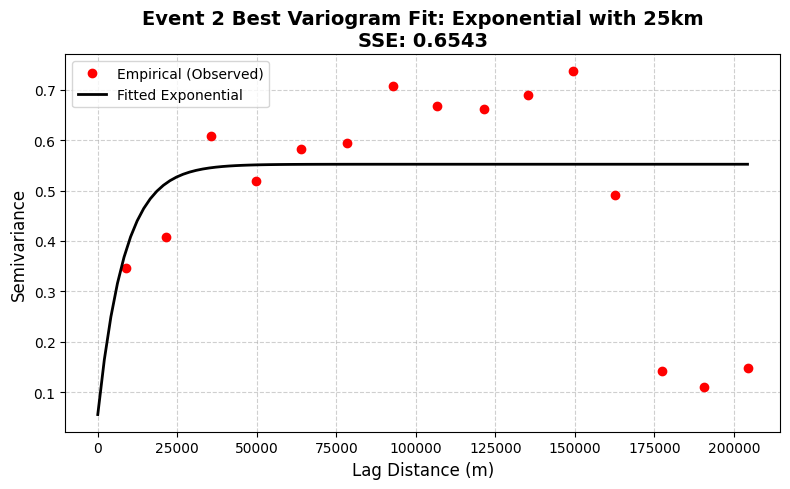

In [35]:
# ==========================================
# 🟣 修正 Step 2b: 事件二 (豪雨) Variogram 模型對決
# ==========================================
import matplotlib.pyplot as plt
import numpy as np
from pykrige.ok import OrdinaryKriging
import warnings

# 【終極防呆】：強制洗掉字體設定，並把 matplotlib 警告靜音
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'sans-serif']
warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib.font_manager")

print("Step 2b: 啟動事件二 (豪雨) Variogram 模型與參數對決測試...\n")

# 1. 降雨數據 Log 轉換 (假設原始變數是 z2，若你已經有 z2_log 請自行替換)
z2_log = np.log1p(z2)

# 2. 設定豪雨的合理測試範圍 (豪雨影響範圍廣，設定較大的 Range 測試)
ranges_km = [100, 75, 50, 25, 15]
models = ['spherical', 'exponential']
sse_results = {}

# 3. 設定並印出共通的初始 Sill 與 Nugget (由資料本身變異數計算)
sill_init = float(np.var(z2_log))
nugget_init = sill_init * 0.1

print(f"📌 使用的初始優化參數 (Initial Parameters):")
print(f"   - Sill (基台值):   {sill_init:.3f}")
print(f"   - Nugget (塊狀效應): {nugget_init:.3f}\n")

# 準備紀錄最佳解的變數
best_combo_str = ""
min_sse = float('inf')
best_ok_model = None
best_model_name = ""
best_params = None

# 4. 開始訓練與評估迴圈
for model_name in models:
    for r_km in ranges_km:
        r_m = r_km * 1000.0  # 轉換為公尺

        # 建立並訓練 Kriging 模型 (精準字典給定參數)
        ok_test = OrdinaryKriging(
            x2, y2, z2_log,
            variogram_model=model_name,
            verbose=False,
            enable_plotting=False,
            nlags=15,
            variogram_parameters={'sill': sill_init, 'range': r_m, 'nugget': nugget_init}
        )

        # 提取實驗變異圖資料與模型參數
        lags = ok_test.lags
        semi_var = ok_test.semivariance
        params = ok_test.variogram_model_parameters
        fitted_func = ok_test.variogram_function

        # 計算預測曲線與 SSE (Sum of Squared Errors)
        fitted_var = fitted_func(params, lags)
        sse = np.sum((semi_var - fitted_var)**2)
        sse_results[f"{model_name}_{r_km}"] = sse

        # 更新最佳紀錄與儲存模型物件
        if sse < min_sse:
            min_sse = sse
            best_combo_str = f"{model_name.capitalize()} with {r_km}km"
            best_ok_model = ok_test
            best_model_name = model_name
            best_params = params

# ==========================================
# 5. 印出 SSE 總結比較表與最佳模型
# ==========================================
print("="*45)
print(f"📊 Event 2: Variogram Model SSE Summary Table")
print("="*45)
print(f"{'Model Type':<15} | {'Initial Range':<15} | {'SSE (Error)':<10}")
print("-" * 45)

# 依序印出結果
for model_name in models:
    for r_km in ranges_km:
        key = f"{model_name}_{r_km}"
        current_sse = sse_results[key]
        marker = "  <--- Best!" if current_sse == min_sse else ""
        print(f"{model_name.capitalize():<15} | {r_km:>10} km    | {current_sse:.5f}{marker}")

print("="*45)
print(f"\n🏆 最終診斷結論：")
print(f"👉 【 {best_combo_str} 】 (SSE: {min_sse:.5f})")

# ==========================================
# 6. 繪製唯一的最佳模型圖表
# ==========================================
plt.figure(figsize=(8, 5))

# 提取最佳模型的資料
lags_best = best_ok_model.lags
semi_var_best = best_ok_model.semivariance
fitted_func_best = best_ok_model.variogram_function

# 繪製 Empirical (實驗變異圖紅點)
plt.plot(lags_best, semi_var_best, 'ro', label='Empirical (Observed)')

# 繪製 Fitted curve (擬合黑線)
smooth_lags = np.linspace(0, max(lags_best), 100)
smooth_fitted = fitted_func_best(best_params, smooth_lags)
plt.plot(smooth_lags, smooth_fitted, 'k-', linewidth=2, label=f'Fitted {best_model_name.capitalize()}')

# 設定標題與標籤
plt.title(f'Event 2 Best Variogram Fit: {best_combo_str}\nSSE: {min_sse:.4f}', fontsize=14, fontweight='bold')
plt.xlabel('Lag Distance (m)', fontsize=12)
plt.ylabel('Semivariance', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# ==========================================
# 7. 將最佳模型指派給全域變數，供 Step 3 產製地圖使用
# ==========================================
ok_sph2 = best_ok_model

##Step 3a Event 1: 四內插法比較 (NN, IDW, Kriging, Random Forest)
建立 1000m 解析度網格，比較不同演算法的空間預測結果，並產出差異圖以檢視演算法的分歧點。

Step 3a: 執行事件一四種內插計算...


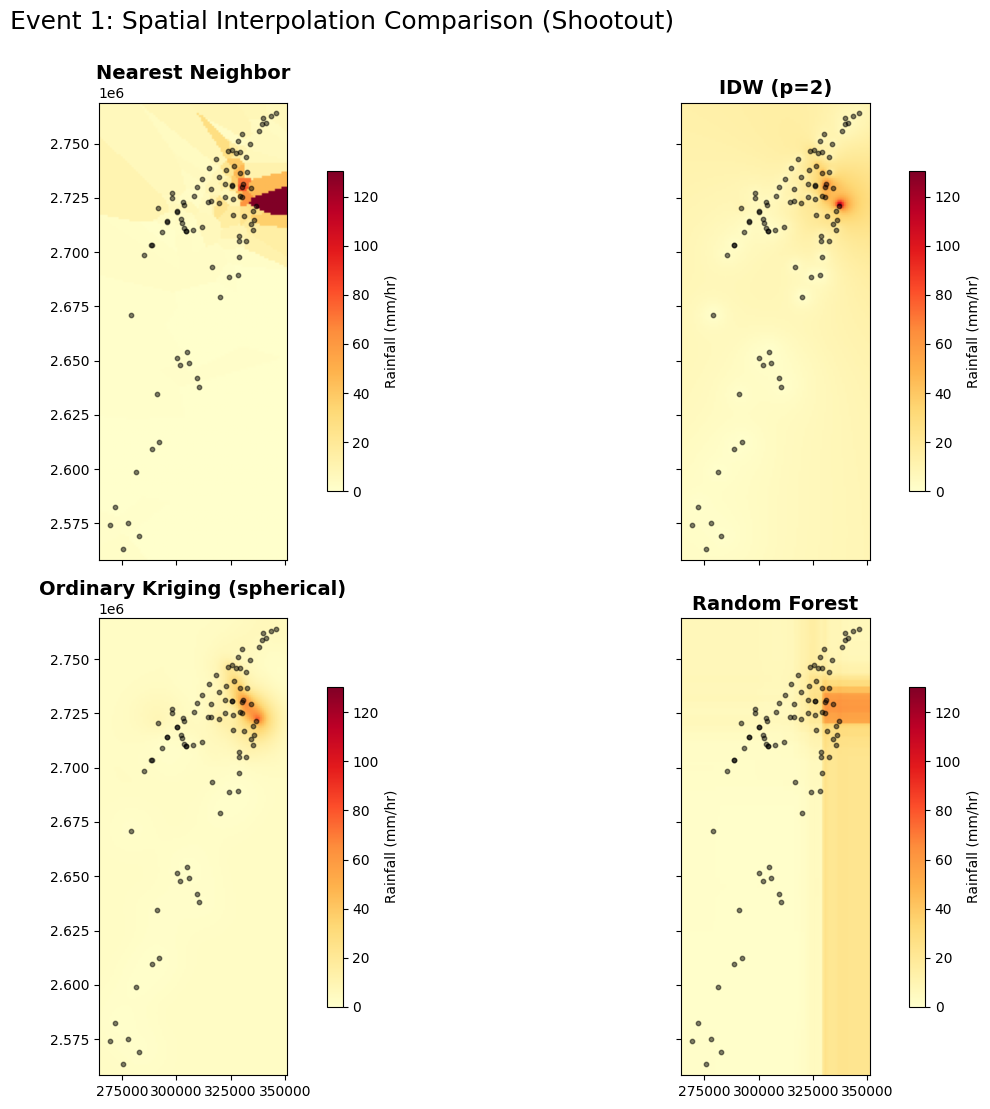

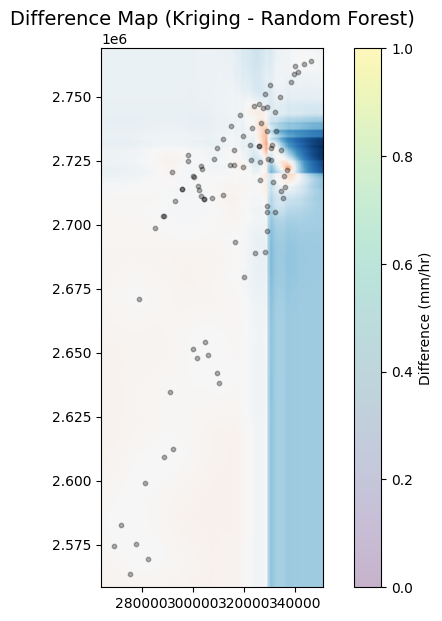

In [36]:
# ==========================================
# Step 3a: 事件一 (鳳凰颱風) 四種內插大對決
# ==========================================
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import NearestNDInterpolator
from sklearn.ensemble import RandomForestRegressor

print("Step 3a: 執行事件一四種內插計算...")

# 1. 建立 1000m 解析度的統一網格
buffer = 5000
x_min, x_max = x1.min() - buffer, x1.max() + buffer
y_min, y_max = y1.min() - buffer, y1.max() + buffer
grid_x = np.arange(x_min, x_max, 1000)
grid_y = np.arange(y_min, y_max, 1000)
grid_xx, grid_yy = np.meshgrid(grid_x, grid_y)

# 2. 演算法 A: Nearest Neighbor (NN)
nn_interp = NearestNDInterpolator(list(zip(x1, y1)), z1)
z_nn = nn_interp(grid_xx, grid_yy)

# 3. 演算法 B: Inverse Distance Weighting (IDW)
def idw_interpolation(x, y, z, xi, yi, p=2):
    dist = np.sqrt((x[:, None, None] - xi)**2 + (y[:, None, None] - yi)**2)
    dist = np.maximum(dist, 1e-9) # 避免除以 0
    weight = 1.0 / (dist**p)
    z_idw = np.sum(weight * z[:, None, None], axis=0) / np.sum(weight, axis=0)
    return z_idw

z_idw = idw_interpolation(x1, y1, z1, grid_xx, grid_yy)

# 4. 演算法 C: Ordinary Kriging (使用 Step 2 選出的最佳模型)
# 記得是在 Log 空間計算，算完要用 expm1 轉回正常單位
ok_model_final = ok_sph1 if best_model_ev1 == 'spherical' else ok_exp1
z_log_krig, _ = ok_model_final.execute('grid', grid_x, grid_y)
z_kriging = np.expm1(z_log_krig)

# 5. 演算法 D: Random Forest (RF)
# 參數依作業要求：n_estimators=200, min_samples_leaf=3
rf_model = RandomForestRegressor(n_estimators=200, min_samples_leaf=3, random_state=42)
rf_model.fit(np.column_stack([x1, y1]), z1)
z_rf = rf_model.predict(np.column_stack([grid_xx.ravel(), grid_yy.ravel()])).reshape(grid_xx.shape)

# 6. 繪製 2x2 比較圖
fig, axes = plt.subplots(2, 2, figsize=(14, 12), sharex=True, sharey=True)
extent = [x_min, x_max, y_min, y_max]
vmax = z1.max() # 統一色階最大值

methods = [
    ('Nearest Neighbor', z_nn),
    ('IDW (p=2)', z_idw),
    (f'Ordinary Kriging ({best_model_ev1})', z_kriging),
    ('Random Forest', z_rf)
]

for i, (title, result) in enumerate(methods):
    ax = axes[i//2, i%2]
    im = ax.imshow(result, extent=extent, origin='lower', cmap='YlOrRd', vmin=0, vmax=vmax)
    ax.scatter(x1, y1, c='black', s=10, alpha=0.5) # 標示測站
    ax.set_title(title, fontsize=14, fontweight='bold')
    plt.colorbar(im, ax=ax, shrink=0.7, label='Rainfall (mm/hr)')

plt.suptitle('Event 1: Spatial Interpolation Comparison (Shootout)', fontsize=18, y=0.95)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# ---------------------------------------------------------
# ⚔️ 額外加碼：Kriging vs RF 差異圖 (Difference Map)
# ---------------------------------------------------------
diff_map = z_kriging - z_rf
max_abs_diff = np.max(np.abs(diff_map))

plt.figure(figsize=(8, 7))
plt.imshow(diff_map, extent=extent, origin='lower', cmap='RdBu_r', vmin=-max_abs_diff, vmax=max_abs_diff)
plt.scatter(x1, y1, c='black', s=10, alpha=0.3)
plt.title('Difference Map (Kriging - Random Forest)', fontsize=14)
plt.colorbar(label='Difference (mm/hr)')
plt.show()

##Step 3b Event 2: 四內插法比較 (NN, IDW, Kriging, Random Forest)
同Step 3b

Step 3b: 執行事件二四種內插計算...


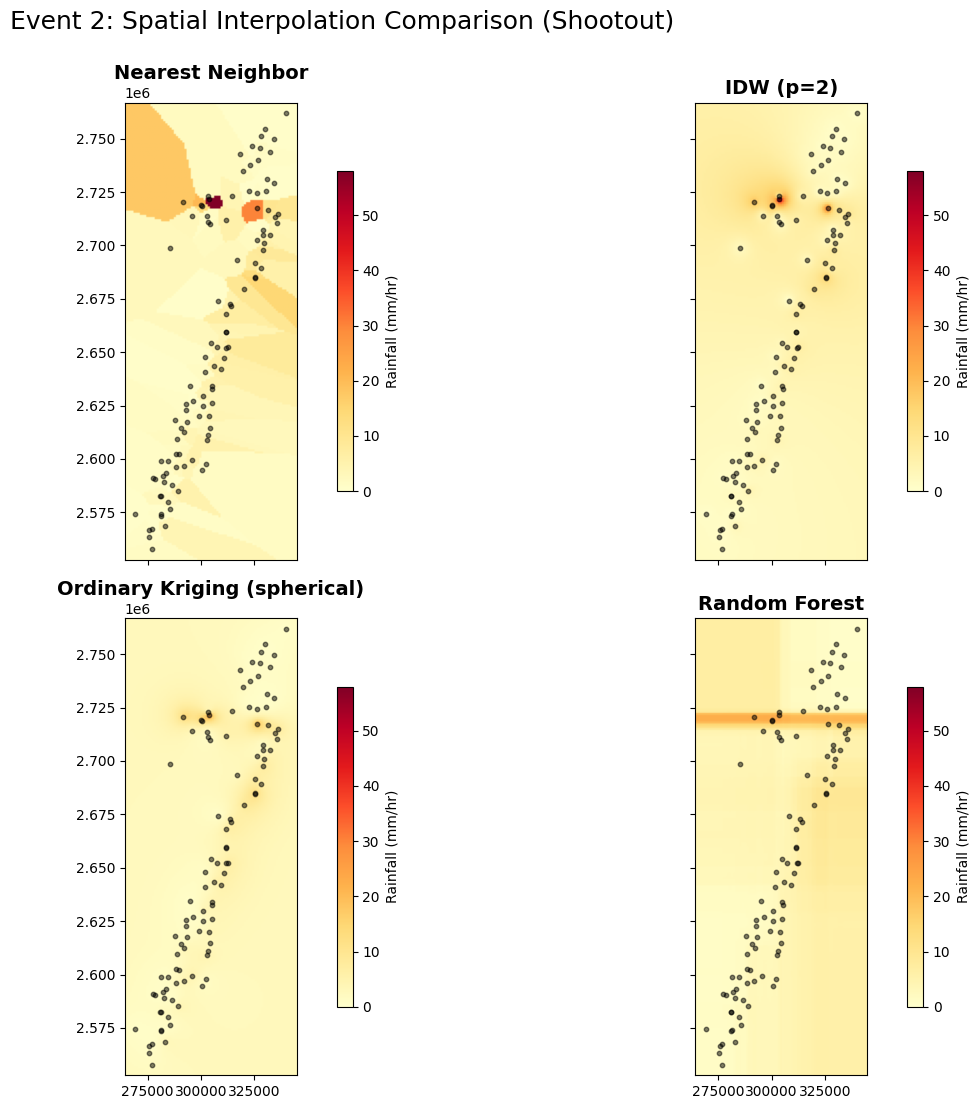

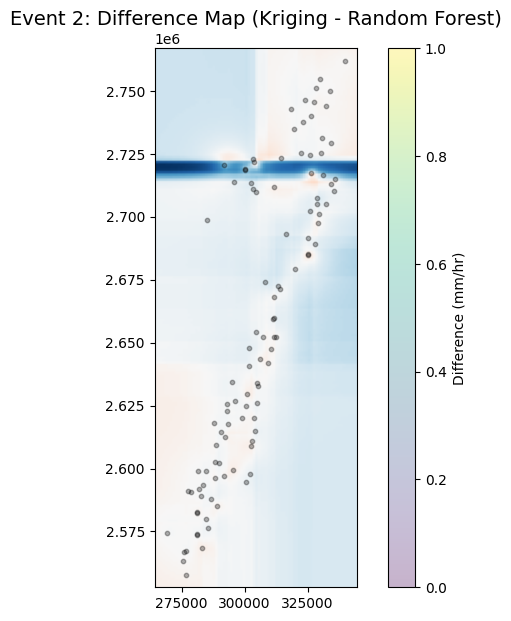

In [37]:
# ==========================================
# Step 3b: 事件二 (10/30 共伴效應) 四種內插大對決
# ==========================================
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import NearestNDInterpolator
from sklearn.ensemble import RandomForestRegressor

print("Step 3b: 執行事件二四種內插計算...")

# 1. 建立 1000m 解析度的統一網格
buffer2 = 5000
x_min2, x_max2 = x2.min() - buffer2, x2.max() + buffer2
y_min2, y_max2 = y2.min() - buffer2, y2.max() + buffer2
grid_x2 = np.arange(x_min2, x_max2, 1000)
grid_y2 = np.arange(y_min2, y_max2, 1000)
grid_xx2, grid_yy2 = np.meshgrid(grid_x2, grid_y2)

# 2. 演算法 A: Nearest Neighbor (NN)
nn_interp2 = NearestNDInterpolator(list(zip(x2, y2)), z2)
z_nn2 = nn_interp2(grid_xx2, grid_yy2)

# 3. 演算法 B: Inverse Distance Weighting (IDW)
# 直接沿用 Step 3a 定義過的 idw_interpolation 函數
z_idw2 = idw_interpolation(x2, y2, z2, grid_xx2, grid_yy2)

# 4. 演算法 C: Ordinary Kriging (使用 Step 2b 選出的最佳模型)
ok_model_final2 = ok_sph2 if best_model_ev2 == 'spherical' else ok_exp2
z_log_krig2, _ = ok_model_final2.execute('grid', grid_x2, grid_y2)
z_kriging2 = np.expm1(z_log_krig2)

# 5. 演算法 D: Random Forest (RF)
rf_model2 = RandomForestRegressor(n_estimators=200, min_samples_leaf=3, random_state=42)
rf_model2.fit(np.column_stack([x2, y2]), z2)
z_rf2 = rf_model2.predict(np.column_stack([grid_xx2.ravel(), grid_yy2.ravel()])).reshape(grid_xx2.shape)

# 6. 繪製 2x2 比較圖
fig, axes = plt.subplots(2, 2, figsize=(14, 12), sharex=True, sharey=True)
extent2 = [x_min2, x_max2, y_min2, y_max2]
vmax2 = z2.max() # 統一色階最大值

methods2 = [
    ('Nearest Neighbor', z_nn2),
    ('IDW (p=2)', z_idw2),
    (f'Ordinary Kriging ({best_model_ev2})', z_kriging2),
    ('Random Forest', z_rf2)
]

for i, (title, result) in enumerate(methods2):
    ax = axes[i//2, i%2]
    im = ax.imshow(result, extent=extent2, origin='lower', cmap='YlOrRd', vmin=0, vmax=vmax2)
    ax.scatter(x2, y2, c='black', s=10, alpha=0.5) # 標示測站
    ax.set_title(title, fontsize=14, fontweight='bold')
    plt.colorbar(im, ax=ax, shrink=0.7, label='Rainfall (mm/hr)')

plt.suptitle('Event 2: Spatial Interpolation Comparison (Shootout)', fontsize=18, y=0.95)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# ---------------------------------------------------------
# ⚔️ 額外加碼：Kriging vs RF 差異圖 (Difference Map)
# ---------------------------------------------------------
diff_map2 = z_kriging2 - z_rf2
max_abs_diff2 = np.max(np.abs(diff_map2))

plt.figure(figsize=(8, 7))
plt.imshow(diff_map2, extent=extent2, origin='lower', cmap='RdBu_r', vmin=-max_abs_diff2, vmax=max_abs_diff2)
plt.scatter(x2, y2, c='black', s=10, alpha=0.3)
plt.title('Event 2: Difference Map (Kriging - Random Forest)', fontsize=14)
plt.colorbar(label='Difference (mm/hr)')
plt.show()

##Step 4a Event 1: Sigma Map
透過 Kriging 的 Variance Map 觀察預測信心最低的區域。

Step 4a: 產製事件一不確定性地圖 (Sigma Map)


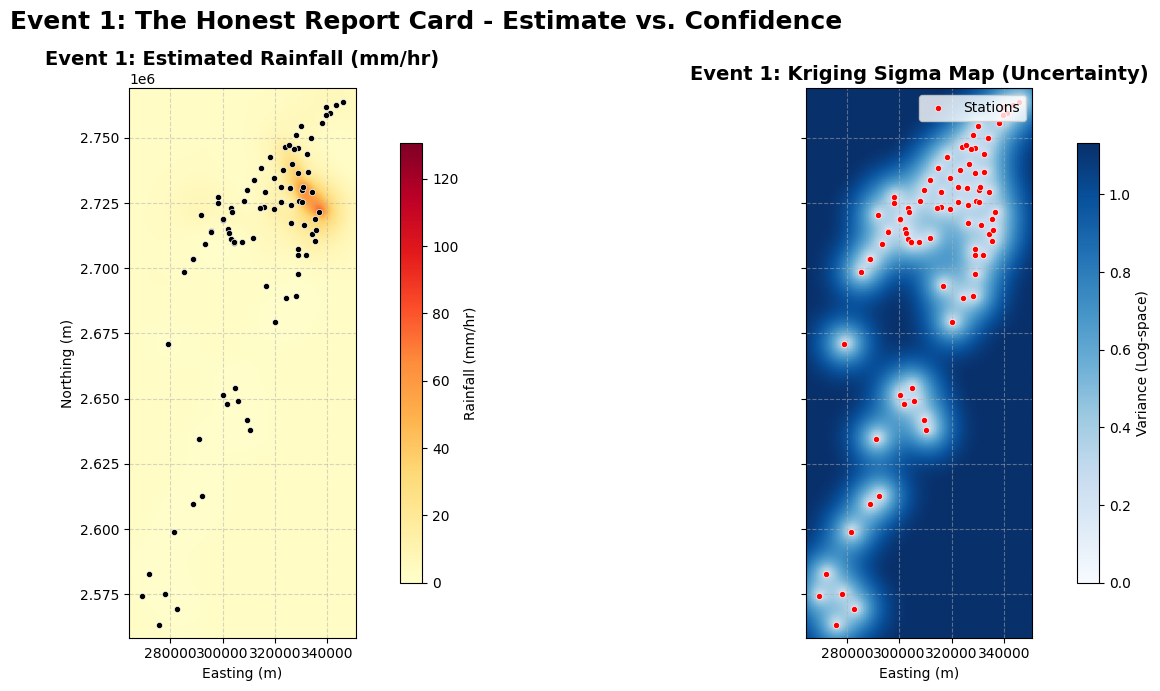

In [38]:
# ==========================================
# Step 4a: 事件一 (鳳凰颱風) Sigma Map
# ==========================================
print("Step 4a: 產製事件一不確定性地圖 (Sigma Map)")

# 1. 計算 Kriging Variance (對數空間下的變異數)
_, z_var_log1 = ok_model_final.execute('grid', grid_x, grid_y)

# 2. 繪製 1x2 比較圖
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

# 左圖：降雨預測
im1 = axes[0].imshow(z_kriging, extent=extent, origin='lower', cmap='YlOrRd', vmin=0, vmax=vmax)
axes[0].scatter(x1, y1, c='black', s=20, edgecolor='white', linewidths=0.5, zorder=5)
axes[0].set_title('Event 1: Estimated Rainfall (mm/hr)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Easting (m)')
axes[0].set_ylabel('Northing (m)')
axes[0].grid(True, linestyle='--', alpha=0.5)
plt.colorbar(im1, ax=axes[0], shrink=0.8, label='Rainfall (mm/hr)')

# 右圖：不確定性 (Variance)
im2 = axes[1].imshow(z_var_log1, extent=extent, origin='lower', cmap='Blues', vmin=0)
axes[1].scatter(x1, y1, c='red', s=20, edgecolor='white', linewidths=0.5, zorder=5, label='Stations')
axes[1].set_title('Event 1: Kriging Sigma Map (Uncertainty)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Easting (m)')
axes[1].legend(loc='upper right')
axes[1].grid(True, linestyle='--', alpha=0.5)
plt.colorbar(im2, ax=axes[1], shrink=0.8, label='Variance (Log-space)')

plt.suptitle('Event 1: The Honest Report Card - Estimate vs. Confidence', fontsize=18, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

## Step 4b Event 2: Sigma Map


Step 4b: 產製事件二不確定性地圖 (Sigma Map)


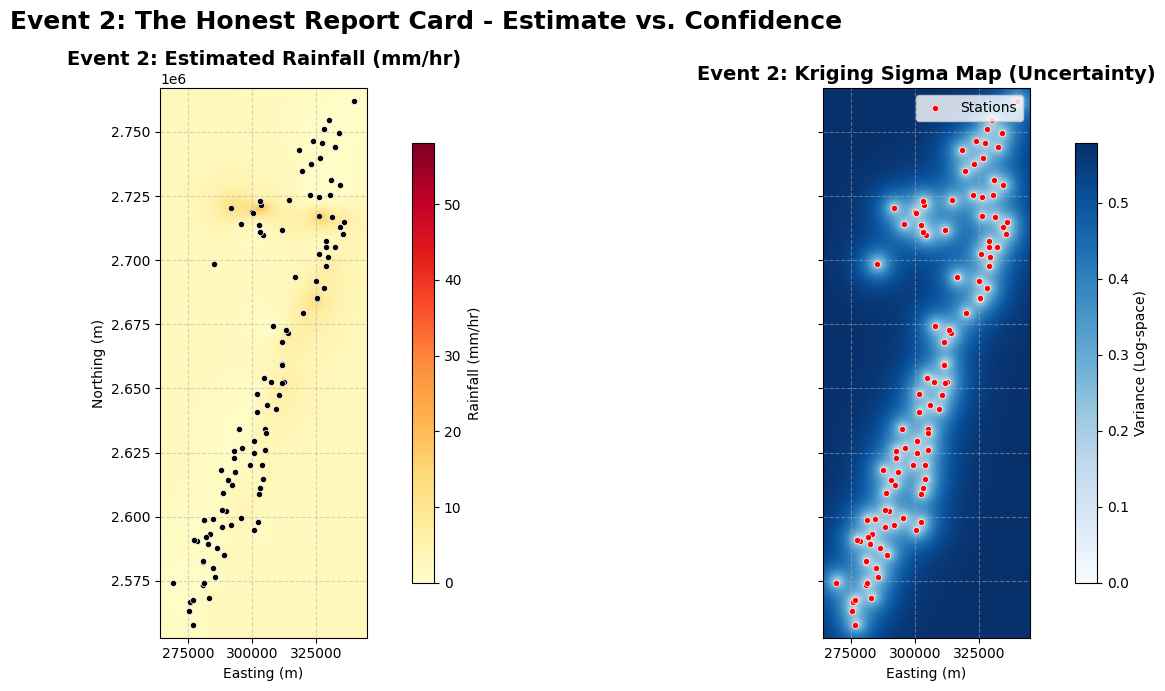

In [39]:
# ==========================================
# Step 4b: 事件二 (10/30 共伴效應) Sigma Map
# ==========================================
print("\nStep 4b: 產製事件二不確定性地圖 (Sigma Map)")

# 1. 計算 Kriging Variance (對數空間下的變異數)
_, z_var_log2 = ok_model_final2.execute('grid', grid_x2, grid_y2)

# 2. 繪製 1x2 比較圖
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

# 左圖：降雨預測
im3 = axes[0].imshow(z_kriging2, extent=extent2, origin='lower', cmap='YlOrRd', vmin=0, vmax=vmax2)
axes[0].scatter(x2, y2, c='black', s=20, edgecolor='white', linewidths=0.5, zorder=5)
axes[0].set_title('Event 2: Estimated Rainfall (mm/hr)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Easting (m)')
axes[0].set_ylabel('Northing (m)')
axes[0].grid(True, linestyle='--', alpha=0.5)
plt.colorbar(im3, ax=axes[0], shrink=0.8, label='Rainfall (mm/hr)')

# 右圖：不確定性 (Variance)
im4 = axes[1].imshow(z_var_log2, extent=extent2, origin='lower', cmap='Blues', vmin=0)
axes[1].scatter(x2, y2, c='red', s=20, edgecolor='white', linewidths=0.5, zorder=5, label='Stations')
axes[1].set_title('Event 2: Kriging Sigma Map (Uncertainty)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Easting (m)')
axes[1].legend(loc='upper right')
axes[1].grid(True, linestyle='--', alpha=0.5)
plt.colorbar(im4, ax=axes[1], shrink=0.8, label='Variance (Log-space)')

plt.suptitle('Event 2: The Honest Report Card - Estimate vs. Confidence', fontsize=18, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

## Step 5 綜合診斷報告 (Cross-Event Comparison)

將 A3.不確定性分析之要求與 A5.跨事件綜合比較合併於此

### 1. Variogram 參數差異比較表 (A1 & A5)
| 參數 | [鳳凰颱風] | [10/30共伴豪雨] | 差異原因分析 (Sill看天氣/Range看地理/Nugget看儀器) |
|---|---|---|---|
| Sill | 1.076 | 0.552 | 鳳凰颱風的降雨極度集中且猛烈，受地形抬升影響，迎風面與背風面的雨量落差極大，導致全區的總體空間變異（Sill）極高。共伴豪雨則是大範圍、連續性的雲系籠罩，各地降雨量相對均勻，因此空間變異數只有颱風的一半。 |
| Range | 25 | 25 | 兩種截然不同的天氣系統，最後都收斂在 25km。這強烈暗示在宜蘭、花蓮這種「西側高山、東側面海」的狹長破碎地形中，降雨的空間連貫性（不論雨勢大小）通常在 25 公里左右就會被山脈稜線或地形阻斷。這是地理環境加諸於天氣系統的自然邊界。 |
| Nugget | 0.108 | 0.055 | Nugget 反映了小於測站間距的微觀變異或儀器誤差。颱風期間伴隨強陣風（例如風切會影響雨量筒收集效率）與亂流，導致局部小尺度的雨量測量雜訊遠高於相對平穩的豪雨系統。 |
| 最佳模型 | Spherical | Spherical | 球狀模型是自然界空間變異最典型的樣態，表示空間相關性會隨距離穩定遞減，並在觸及地形邊界（25km）後完全消失，兩者皆符合此一物理規律。 |

**Q: 如果只能用一組 Variogram 參數套用到未來所有事件，你會怎麼選？為什麼這樣做有風險？(A5)**
> 答：從兩次都衝擊台灣東北部區域為主的降雨事件，可見不論類型，似乎以Range=25km、Spherical模型，可以取得較好的果，至於Sill、Nugget,兩在模擬過程中，本即透過測站數據Var來計算。為應付比較常態發生的均勻性降雨，應該會取用10/30類似的大範圍豪雨型事件之參數來應用。
不過這樣也會抹煞系統動態調適的能力，且在氣候變遷的當代，可能明年和今年的降雨情況就不同，也許如鳳凰颱風的極端式降雨會越來越常出現，則這種統一參數，就容易發生雨量低估、預測區域失準的問題。

### 2. 不確定性與決策分析 (A3)
* **Sigma Map 差異分析**

  兩個事件的 Sigma Map 有什麼差異？為什麼？

  兩事件視覺分布高度相似，因其最佳Range皆為25km，不過鳳凰颱風Variance最大有到1.1，事件二的共伴效應豪雨只有到0.55。係因事件一的鳳凰颱風，為極端且集中之降雨，落差大導致Sill很高。故即使事件二的舊資料、使得被保留的雨量站點位較少、較分散，其變異並不若事件一來得大。

  哪種類型的降雨事件 Kriging 的預測信心較高？

  從上述結果可知，Kriging 對「廣泛均勻型降雨」的預測信心較高，因此降雨類型有更明顯的空間自相關性，故可見Sill較低；變異數小也代表鄰近測站數據更有代表性，Kriging內插結果也越值得信賴。

* **指揮官決策**：

  如果我是指揮官，在高 Variance 區域會做什麼決策？

  高Variance代表模型對這些地方不具有信心，換言之，應該從嚴保守審視；並在其他因子的考慮(如土石流潛勢、社經脆弱等)下，主動蒐集情資，以更準確掌握這些，可能因為偏離測站而存在盲區的點位。更可以考慮歷史資料，做相關的預防性疏散。

* **RF 的限制**：
  
  Random Forest 能提供類似的不確定性資訊嗎？為什麼？

  Kriging是機率統計模型，如課堂練習中所述，天生就會估計站點的誤差範圍；RF則是決定性的機器學習演算法，透過預測結果的平均值提供絕對答案，是黑盒子而不能提供不確定性。

## Step 6 GeoTIFF網格輸出

此挑選10/30共伴效應豪雨，將內插結果匯出為 tif 檔，以便後續進入 QGIS 進行套疊分析。
將 Kriging 結果儲存為 `kriging_rainfall.tif`（EPSG:3826）
2. 將 Kriging variance 儲存為 `kriging_variance.tif`（EPSG:3826）
3. 將 RF 結果儲存為 `rf_rainfall.tif`（EPSG:3826）

In [40]:
# ==========================================
# Step 6: GeoTIFF 網格輸出 (針對 10/30 事件二)
# ==========================================
import os
import rasterio
from rasterio.transform import from_bounds
import numpy as np

print("Step 6: 匯出事件二 (10/30) 空間圖資至 Google Drive")

# 1. 設定儲存路徑
output_dir = '/content/drive/MyDrive/GIS_data/Week6_Class'
os.makedirs(output_dir, exist_ok=True)

# 2. 建立地理轉換矩陣 (使用事件二的邊界與網格大小)
# 注意這裡要用事件二的變數：x_min2, y_min2, x_max2, y_max2
transform = from_bounds(x_min2, y_min2, x_max2, y_max2,
                        width=z_kriging2.shape[1], height=z_kriging2.shape[0])

# 3. 定義共用儲存函數
def save_geotiff(data, filename, crs='EPSG:3826'):
    # ⚠️ 必須上下翻轉 (np.flipud)，否則 QGIS 裡面台灣會上下顛倒
    data_flipped = np.flipud(data).astype(np.float32)
    filepath = os.path.join(output_dir, filename)

    with rasterio.open(
        filepath, 'w',
        driver='GTiff',
        height=data_flipped.shape[0],
        width=data_flipped.shape[1],
        count=1,
        dtype='float32',
        crs=crs,
        transform=transform,
        nodata=-9999
    ) as dst:
        dst.write(data_flipped, 1)

    print(f"  ✓ 成功儲存: {filename}")

# 4. 匯出 10/30 事件的 3 張關鍵地圖
print("正在寫入 GeoTIFF 檔案...")
save_geotiff(z_kriging2, 'Event2_1030_kriging_rainfall.tif')
save_geotiff(z_var_log2, 'Event2_1030_kriging_variance.tif')
save_geotiff(z_rf2, 'Event2_1030_rf_rainfall.tif')

print("\n✅ Part A 全數通關！檔案已儲存，可隨時載入 QGIS 進行套疊。")

Step 6: 匯出事件二 (10/30) 空間圖資至 Google Drive
正在寫入 GeoTIFF 檔案...
  ✓ 成功儲存: Event2_1030_kriging_rainfall.tif
  ✓ 成功儲存: Event2_1030_kriging_variance.tif
  ✓ 成功儲存: Event2_1030_rf_rainfall.tif

✅ Part A 全數通關！檔案已儲存，可隨時載入 QGIS 進行套疊。
